In [64]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region

In [2]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')

In [3]:
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [4]:
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'

In [5]:
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'

In [6]:
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)

In [7]:
df_important_TF.columns=['TF']

In [8]:
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_2743915/313275177.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [9]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [10]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [11]:
outdir

'/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [12]:
df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)

In [13]:
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']

/tmp/ipykernel_2743915/605102179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']


In [14]:
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))

In [15]:
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [16]:
direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]

In [17]:
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [18]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [19]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [20]:
TOBIAS_Rsults = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*/*.bw/bindetect_results.xlsx')

In [21]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    df_expanded = df_tobias.copy()
    df_expanded['TFexpand'] = df_expanded['TF']

    # df_expanded
    df_expanded_mean = df_expanded.groupby('TFexpand').mean()
    df_expanded_mean['TF'] = df_expanded_mean.index
    df_expanded_mean['ctname'] = ctname
    df_expanded_mean['Region'] = region

    full_results = pd.concat([full_results, df_tobias], axis=0)
    results = pd.concat([results, df_expanded_mean], axis=0)

In [22]:
def add_columns(results):
    results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results

In [23]:
full_results = add_columns(full_results)
avg_results = add_columns(results)

In [24]:
full_results[full_results.FDR < 0.05]

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Sex,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,7290,2.28474,1569,3.16458,2330,-0.25633,...,M,Junb,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25633,5.007000e-132,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,7559,2.30070,1643,3.16800,2420,-0.25220,...,M,Fosl2,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25220,3.431600e-135,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,7492,2.22564,1553,3.07302,2283,-0.25169,...,M,Fos,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25169,2.404770e-130,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,7562,2.30559,1645,3.17551,2422,-0.25143,...,M,Jun,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25143,6.015440e-134,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2520,metacluster_50.1homer__NATGASTCABNN_Fosl2_None,metacluster_50.1#homer__NATGASTCABNN_Fosl2,None,C_metacluster_50.1#transfac_public__M00038,7367,2.28692,1581,3.15783,2343,-0.25110,...,M,Fosl2,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25110,2.395590e-134,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,metacluster_43.2jaspar__MA1618.1_None,metacluster_43.2#jaspar__MA1618.1,None,C_metacluster_193.2#homer__SMCATCTGKH_TCF4,23928,0.43427,6165,0.44990,6691,-0.00147,...,M,Ptf1a,NN,AMY_MOL-2,-0.00147,3.893220e-02,MOL-2,AMY,Down,MOL-2
1845,metacluster_189.2jaspar__MA0768.2_None,metacluster_189.2#jaspar__MA0768.2,None,C_metacluster_189.2#jaspar__MA0768.2,21680,0.37745,4587,0.39490,4908,0.00142,...,M,Lef1,NN,AMY_MOL-2,0.00142,6.263540e-03,MOL-2,AMY,Up,MOL-2
4036,metacluster_165.10homer__TGATKGATGR_HOXA1_None,metacluster_165.10#homer__TGATKGATGR_HOXA1,None,C_metacluster_165.10#swissregulon__hs__HOXA2,12078,0.36641,2505,0.38178,2688,-0.00138,...,M,Hoxa1,NN,AMY_MOL-2,-0.00138,8.677550e-03,MOL-2,AMY,Down,MOL-2
4131,metacluster_18.3hocomoco__NFIC_MOUSE.H11MO.1.A...,metacluster_18.3#hocomoco__NFIC_MOUSE.H11MO.1.A,None,C_metacluster_18.2#hocomoco__NFIC_HUMAN.H11MO.0.A,38994,0.62448,14108,0.64409,14977,0.00135,...,M,Nfic,NN,AMY_MOL-2,0.00135,1.807780e-03,MOL-2,AMY,Up,MOL-2


In [25]:
full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_2743915/1742268152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
/tmp/ipykernel_2743915/1742268152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_2743915/1742268152.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [26]:
full_results_filtered

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,46234,0.13832,9866,0.16497,12193,-0.48882,...,Fos,Glut,PFC_PFC_L4-5_IT_Glut,-0.48882,1.068120e-206,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.48882
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,46862,0.14100,10206,0.16699,12494,-0.46652,...,Fosl2,Glut,PFC_PFC_L4-5_IT_Glut,-0.46652,4.103690e-201,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.46652
1554,metacluster_157.2dbtfbs__mm_FOSL1_C2C12_ENCSR0...,metacluster_157.2#dbtfbs__mm_FOSL1_C2C12_ENCSR...,None,C_metacluster_50.1#transfac_public__M00038,47909,0.13894,10265,0.16424,12530,-0.45869,...,Fosl1,Glut,PFC_PFC_L4-5_IT_Glut,-0.45869,7.784100e-203,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45869
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,45477,0.14093,9849,0.16635,12027,-0.45288,...,Junb,Glut,PFC_PFC_L4-5_IT_Glut,-0.45288,1.249460e-199,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45288
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,48755,0.14066,10542,0.16567,12876,-0.45049,...,Jun,Glut,PFC_PFC_L4-5_IT_Glut,-0.45049,5.300370e-198,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,metacluster_24.2c2h2_zfs__M5280_None,metacluster_24.2#c2h2_zfs__M5280,None,C_metacluster_24.2#c2h2_zfs__M5280,99468,0.68294,24241,0.66356,24226,0.01453,...,Bcl6,Glut,HPF_HPF_Subiculum_SUB_Glut,0.01453,8.568930e-66,HPF_Subiculum_SUB_Glut,HPF,Up,HPF_Subiculum_SUB_Glut,0.01453
3059,metacluster_6.2jaspar__MA0874.1_None,metacluster_6.2#jaspar__MA0874.1,None,C_metacluster_6.2#swissregulon__mm__Esx1,10440,0.16036,4668,0.16015,4782,0.01436,...,Arx,NN,AMY_OPC,0.01436,9.752360e-32,OPC,AMY,Up,OPC,0.01436
2455,metacluster_164.1swissregulon__mm__Meox1_None,metacluster_164.1#swissregulon__mm__Meox1,None,C_metacluster_164.1#swissregulon__mm__Meox1,12145,0.15987,5663,0.15987,5844,0.01432,...,Meox1,NN,AMY_OPC,0.01432,8.085400e-34,OPC,AMY,Up,OPC,0.01432
1136,metacluster_163.1hocomoco__KLF5_MOUSE.H11MO.0....,metacluster_163.1#hocomoco__KLF5_MOUSE.H11MO.0.A,None,C_metacluster_3.7#kznf__SP1_HocoMoco.2_Misc,60800,1.41336,25226,1.47397,26730,0.01423,...,Klf5,NN,HPF_MFOL,0.01423,3.408150e-55,MFOL,HPF,Up,MFOL,0.01423


In [27]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_results_filtered.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [28]:
len(unvalid_files)

0

In [29]:
import dask.dataframe as dd
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [30]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]

In [31]:
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/dask/dataframe/core.py:4158: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('MC_MW_log2fc', 'object'))

  warnings.warn(meta_warning(meta))


In [32]:
df_regions= df_filtered.compute()

In [33]:
df_regions['names'] = df_regions['peak_chr'].astype(str)+':'+df_regions['peak_start'].astype(str)+'-'+df_regions['peak_end'].astype(str)
df_regions['Direction'] = df_regions['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

In [37]:
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"

In [38]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [39]:
df_regions_f = df_regions[df_regions['absLog2FC'] >= 1]
df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

/tmp/ipykernel_2743915/2402002316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)


In [86]:
df_regions_f

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction,TF
150,chr1,15544447,15544459,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.50062,-,chr1,15544168,15544669,0.15077,0.36765,0,1,-1.16783,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,1.16783,PFC_L4-5_IT_Glut,chr1:15544168-15544669,Down,Fos
199,chr1,18578660,18578672,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.18608,+,chr1,18578587,18579088,0.21520,0.46970,1,1,-1.04795,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,1.04795,PFC_L4-5_IT_Glut,chr1:18578587-18579088,Down,Fos
236,chr1,21552897,21552909,metacluster_50.1homer__NDATGASTCAYN_Fos_None,8.99098,-,chr1,21552672,21553173,0.06089,0.17948,0,1,-1.26932,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,1.26932,PFC_L4-5_IT_Glut,chr1:21552672-21553173,Down,Fos
419,chr1,31645194,31645206,metacluster_50.1homer__NDATGASTCAYN_Fos_None,7.71606,+,chr1,31645017,31645518,0.08769,0.19950,0,1,-1.00605,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,1.00605,PFC_L4-5_IT_Glut,chr1:31645017-31645518,Down,Fos
434,chr1,32444076,32444088,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.37196,+,chr1,32443851,32444352,0.09844,0.32668,0,1,-1.52434,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,1.52434,PFC_L4-5_IT_Glut,chr1:32443851-32444352,Down,Fos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10840,chrX,162087634,162087644,metacluster_118.1taipale__Hoxa2_DBD_NNYMATTANN...,7.41043,+,chrX,162087242,162087743,0.58659,0.27694,1,1,1.04454,/data2st2/junyi/output/atac1112/tobiasbam/AMY/...,1.04454,AMY_OPC,chrX:162087242-162087743,Up,Hoxa2
10841,chrX,162279348,162279358,metacluster_118.1taipale__Hoxa2_DBD_NNYMATTANN...,7.60080,+,chrX,162279016,162279517,0.06116,0.14085,0,1,-1.03853,/data2st2/junyi/output/atac1112/tobiasbam/AMY/...,1.03853,AMY_OPC,chrX:162279016-162279517,Down,Hoxa2
10842,chrX,163988340,163988350,metacluster_118.1taipale__Hoxa2_DBD_NNYMATTANN...,7.39032,+,chrX,163987916,163988417,0.03608,0.12935,0,1,-1.50908,/data2st2/junyi/output/atac1112/tobiasbam/AMY/...,1.50908,AMY_OPC,chrX:163987916-163988417,Down,Hoxa2
10843,chrX,166261304,166261314,metacluster_118.1taipale__Hoxa2_DBD_NNYMATTANN...,7.49014,-,chrX,166260931,166261432,0.13343,0.02252,1,0,2.00037,/data2st2/junyi/output/atac1112/tobiasbam/AMY/...,2.00037,AMY_OPC,chrX:166260931-166261432,Up,Hoxa2


In [41]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [ ]:
df_Group = df_regions_f.groupby(['names', 'Region Subclass','Direction'], as_index=False).agg(
    combined_TF=('TF', lambda x: '/'.join(x.astype(str))),
    combined_TFBS=('TFBS_name', lambda x: '/'.join(x.astype(str)))
)


In [42]:
df_regions_peaks = df_regions_f.drop_duplicates(subset=['peak_chr','peak_start','peak_end'])
df_regions_peaks.loc[:, ['peak_chr','peak_start','peak_end']].to_csv('/data2st1/junyi/output/atac1112/tobias/tobias_peaks.bed',sep='\t', index=False,header=False)
df_annotattion = annotate_region(df_regions_peaks,region_col='names', bedfile='/data2st1/junyi/generegion_vM23/genebody_selected.bed')

In [46]:
df_annotattion_columns = df_annotattion.loc[:,['names','gene_name','gene_id','gstart','gend','distance']]

In [47]:
df_merged_region = pd.merge(df_regions_f,df_annotattion_columns,how='left',on='names')

In [49]:
df_merged_region.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv')

In [51]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass'], right_on=['names','Region Subclass'])

In [52]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [ ]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

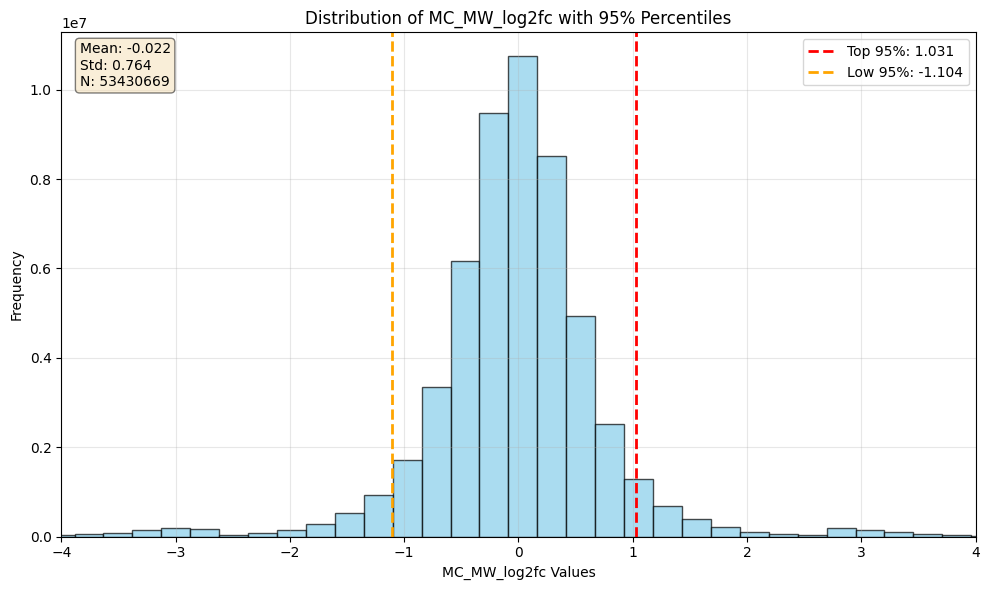

In [50]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [81]:
#results=avg_results[avg_results.FDR <0.05]
results=full_results_filtered
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_2743915/1900155310.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
/tmp/ipykernel_2743915/1900155310.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_2743915/1900155310.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [87]:
avg_results['nlogp'] = -np.log10(avg_results['FDR'] + 1e-300) * np.sign(avg_results['log2FC'])
avg_results['Regulation'] = avg_results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
avg_results['Regulation']=avg_results['Regulation'].astype(float)
avg_results.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_avg_TFs.csv')

In [88]:
full_results_filtered['nlogp'] = -np.log10(full_results_filtered['FDR'] + 1e-300) * np.sign(full_results_filtered['log2FC'])
full_results_filtered['Regulation'] = full_results_filtered['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
full_results_filtered['Regulation']=full_results_filtered['Regulation'].astype(float)
full_results_filtered.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_avg_TFs.csv')
full_results_filtered.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_unique_TFs.csv')

/tmp/ipykernel_2743915/1177677224.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['nlogp'] = -np.log10(full_results_filtered['FDR'] + 1e-300) * np.sign(full_results_filtered['log2FC'])
/tmp/ipykernel_2743915/1177677224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['Regulation'] = full_results_filtered['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_2743915/1177677224.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy 

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


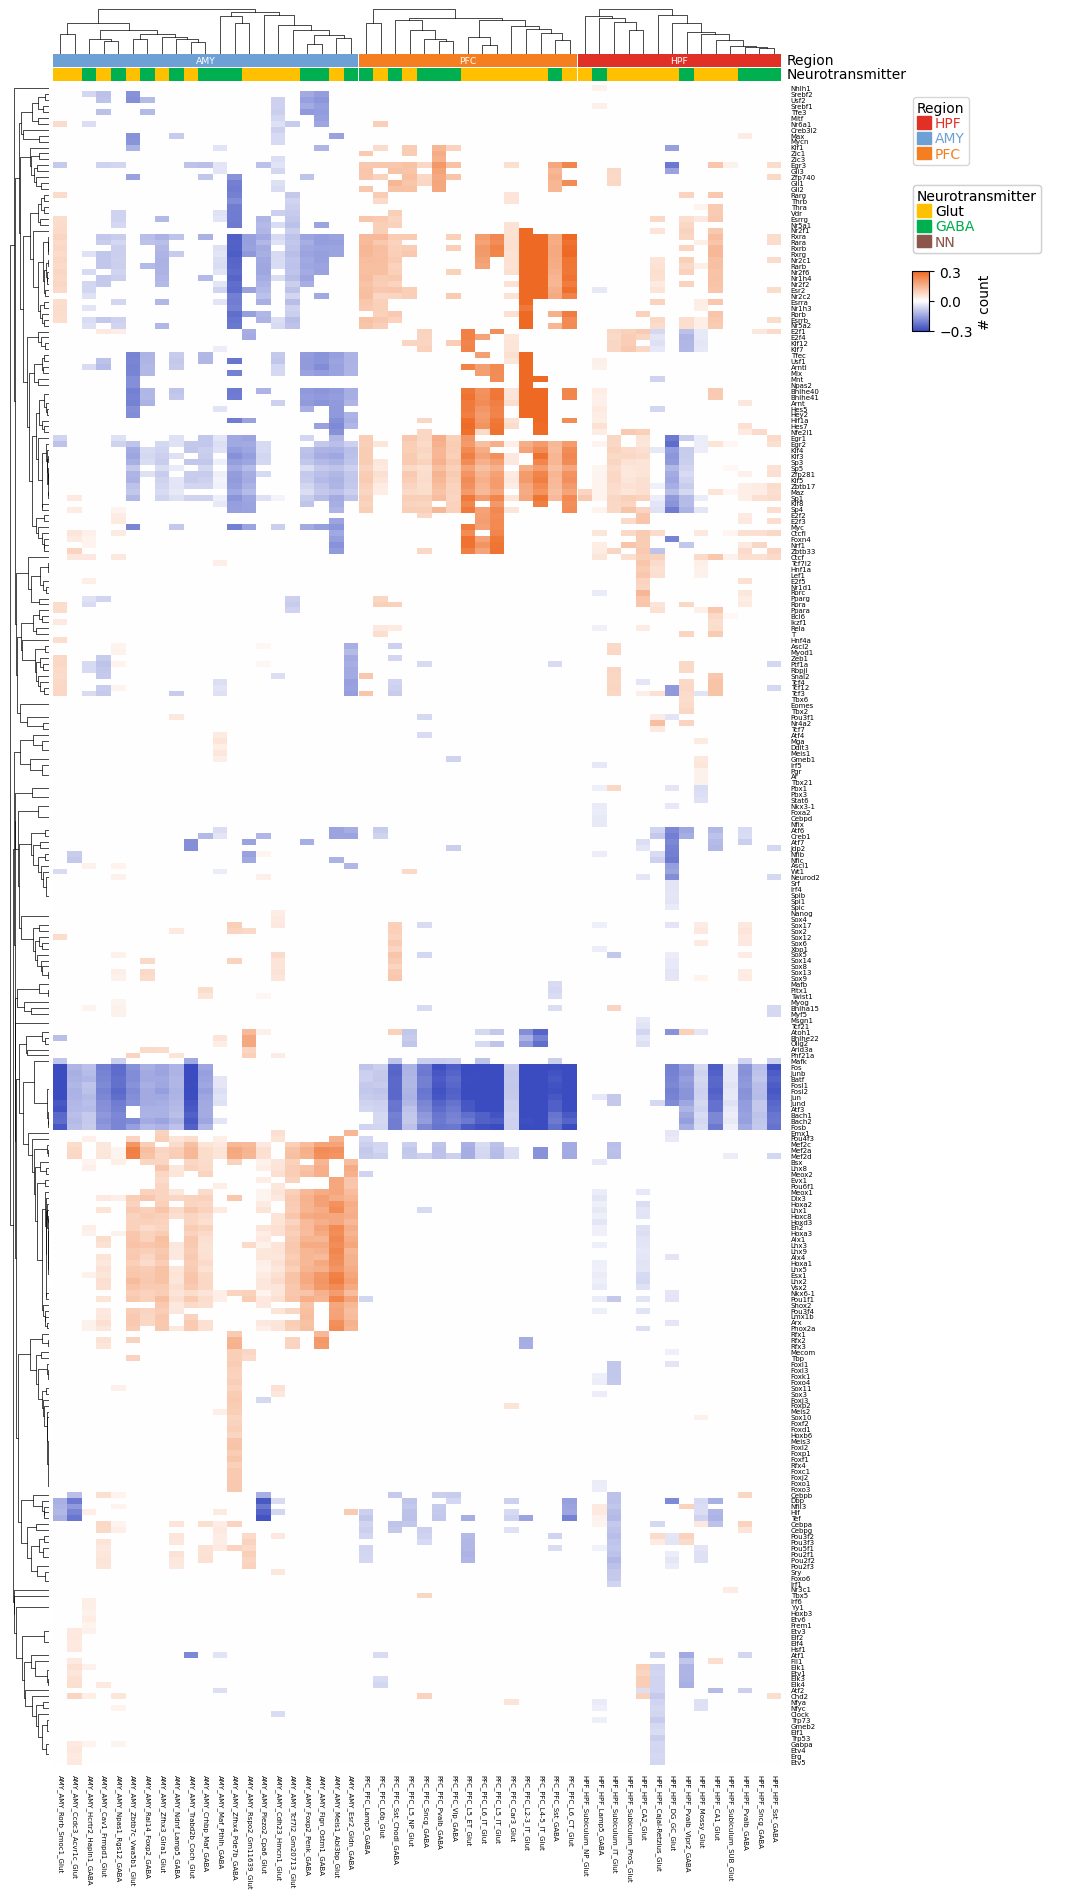

In [82]:
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.3,save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias.pdf')

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


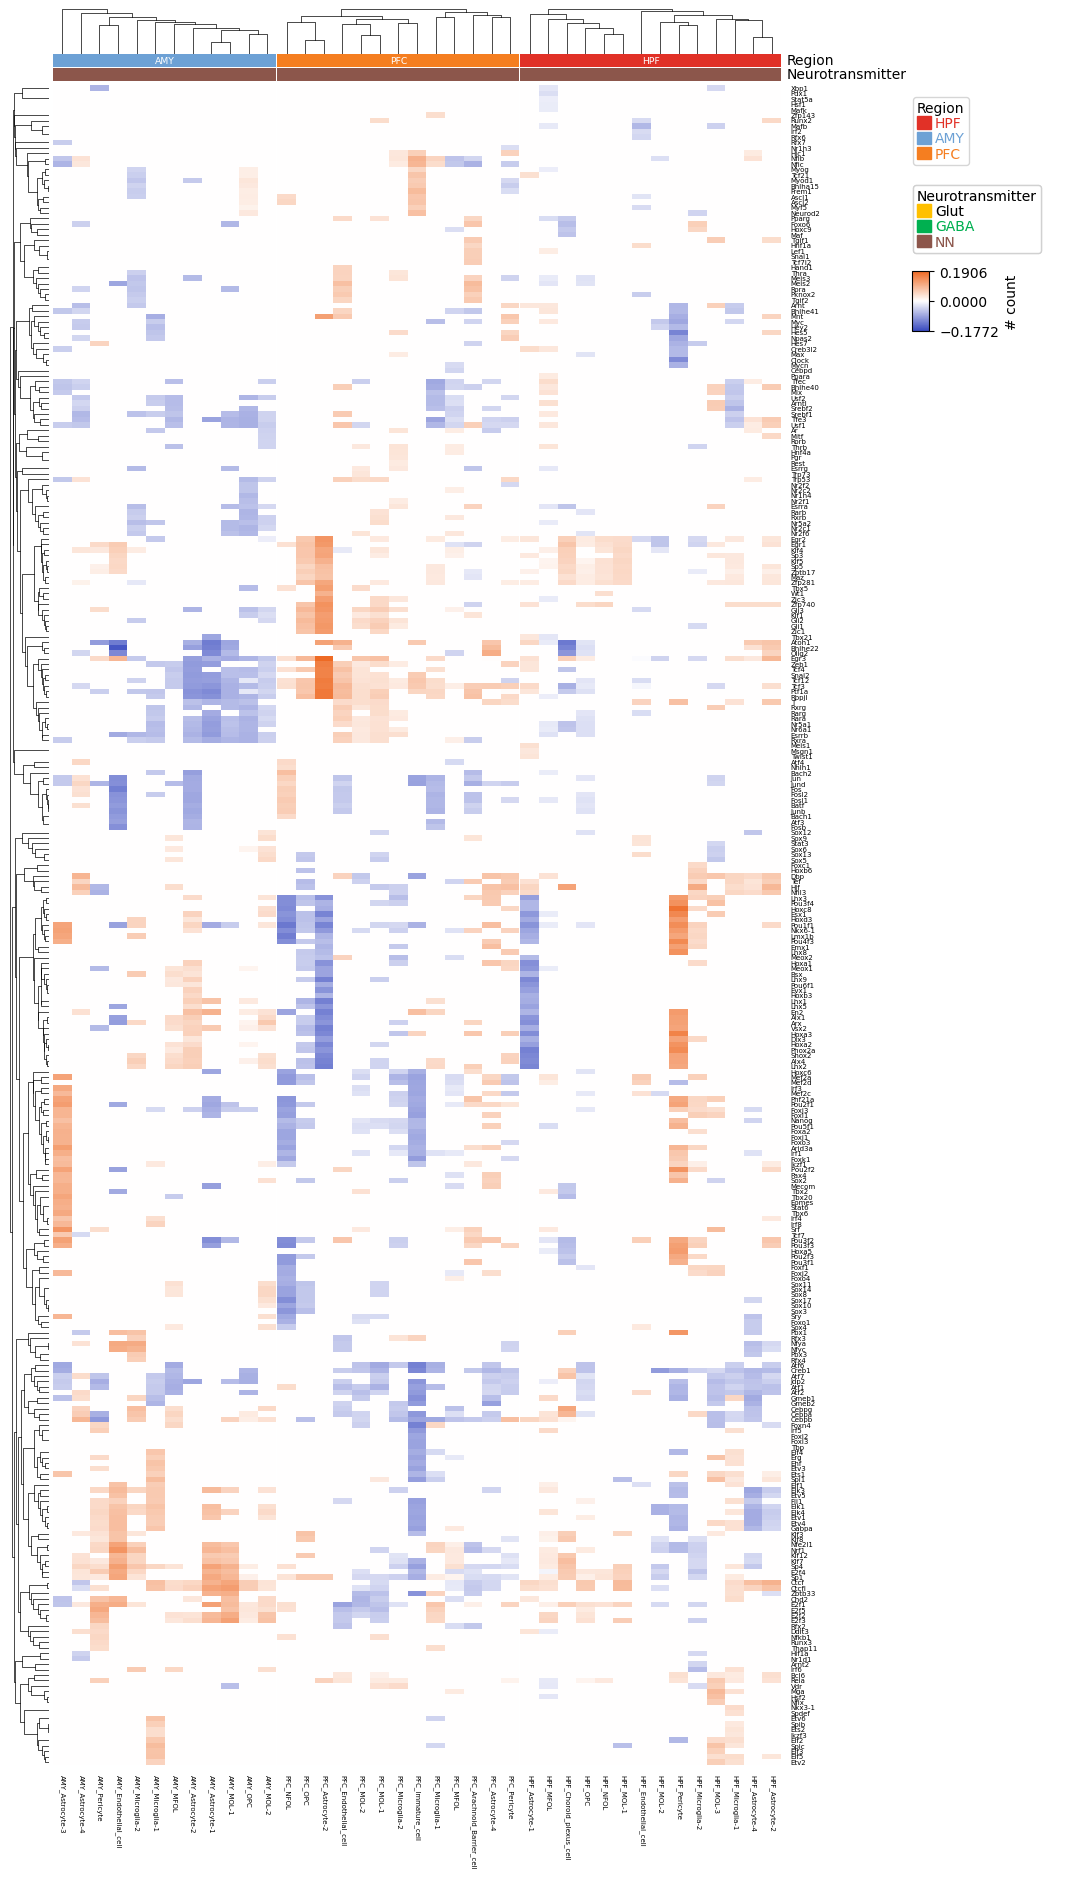

In [94]:
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.3,save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN.pdf')

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


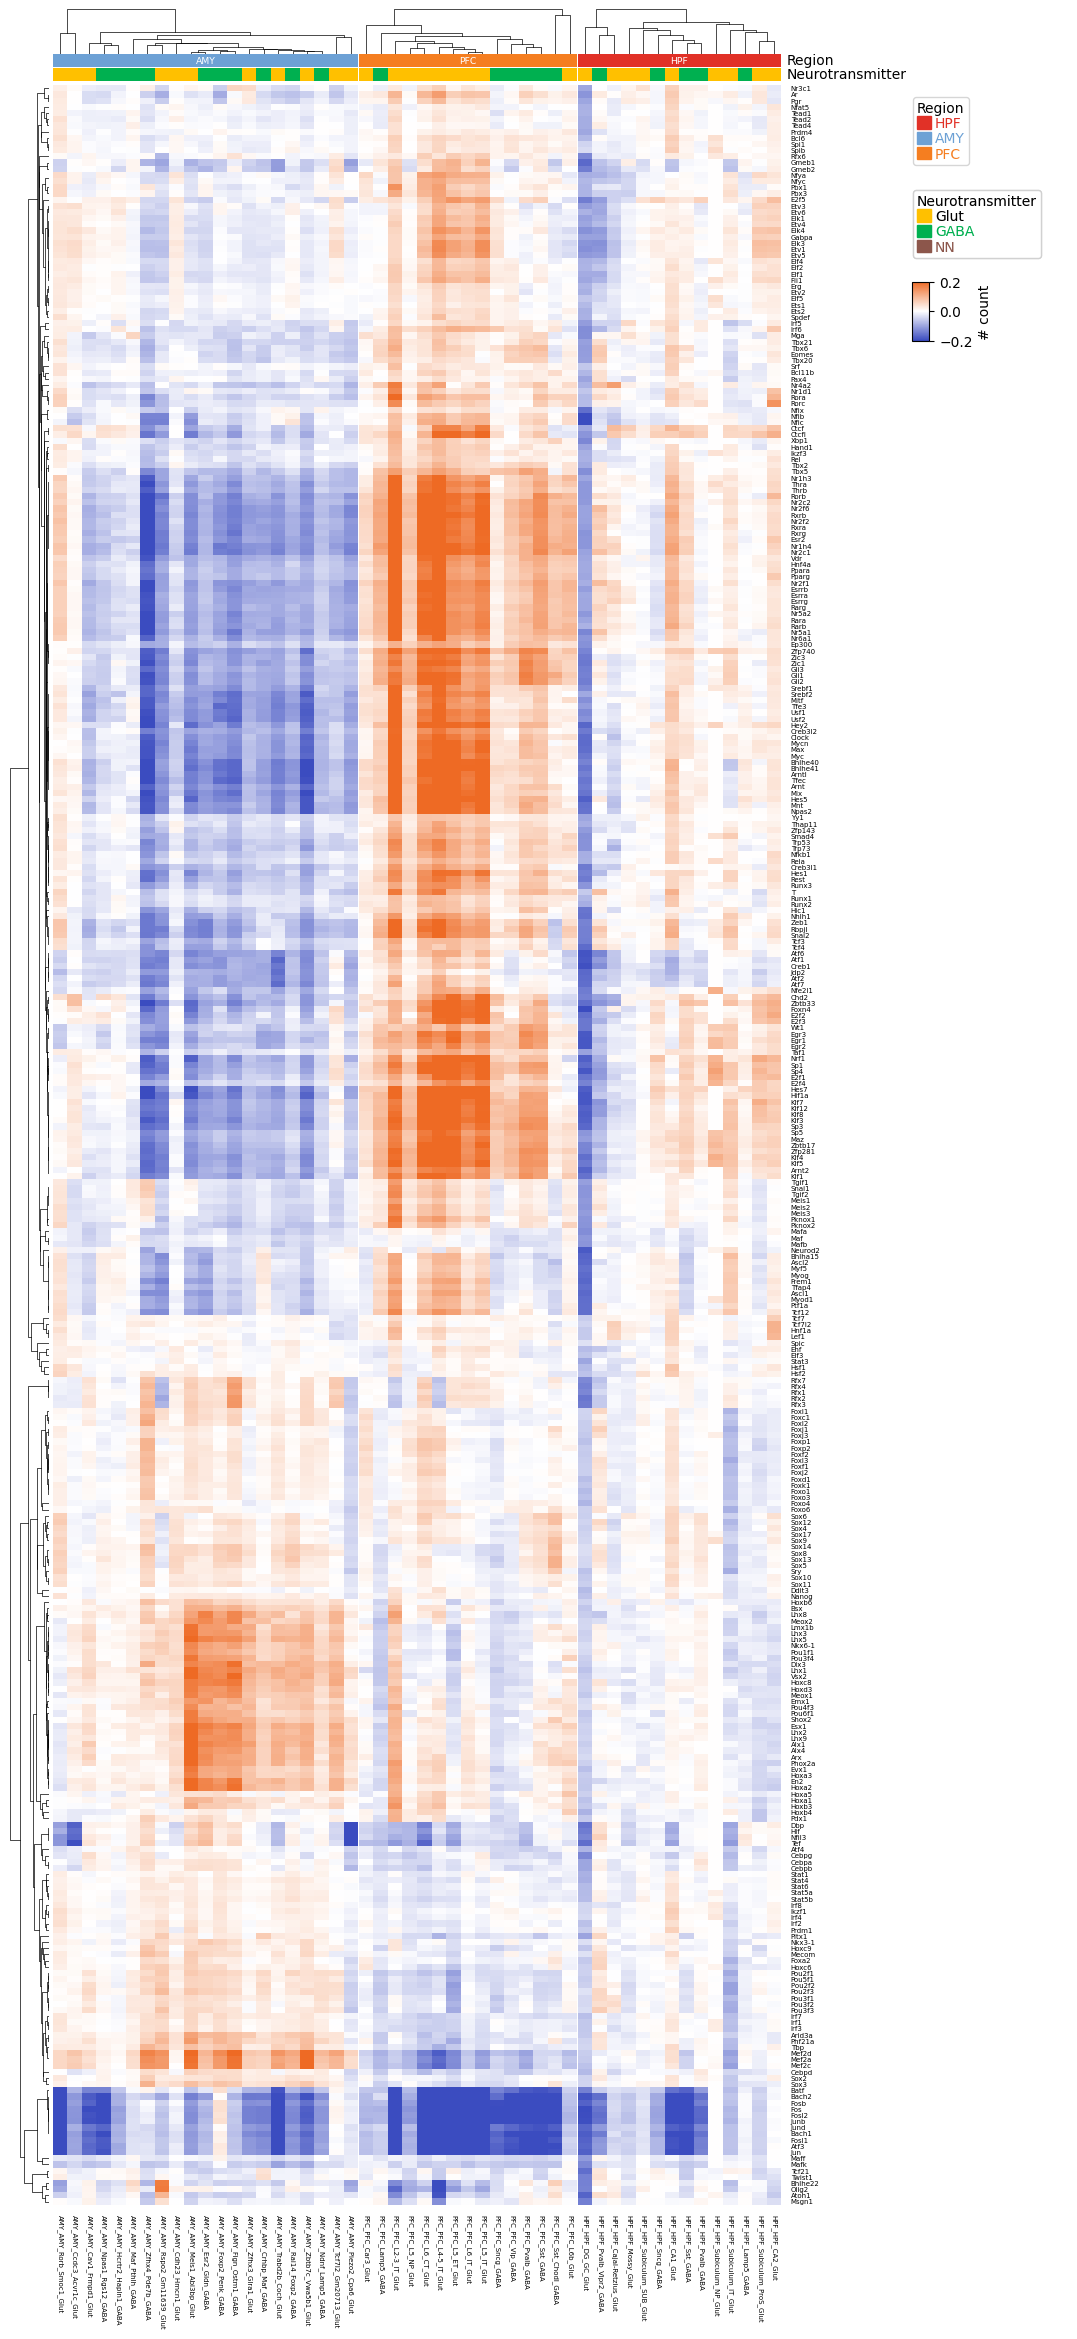

In [92]:
cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


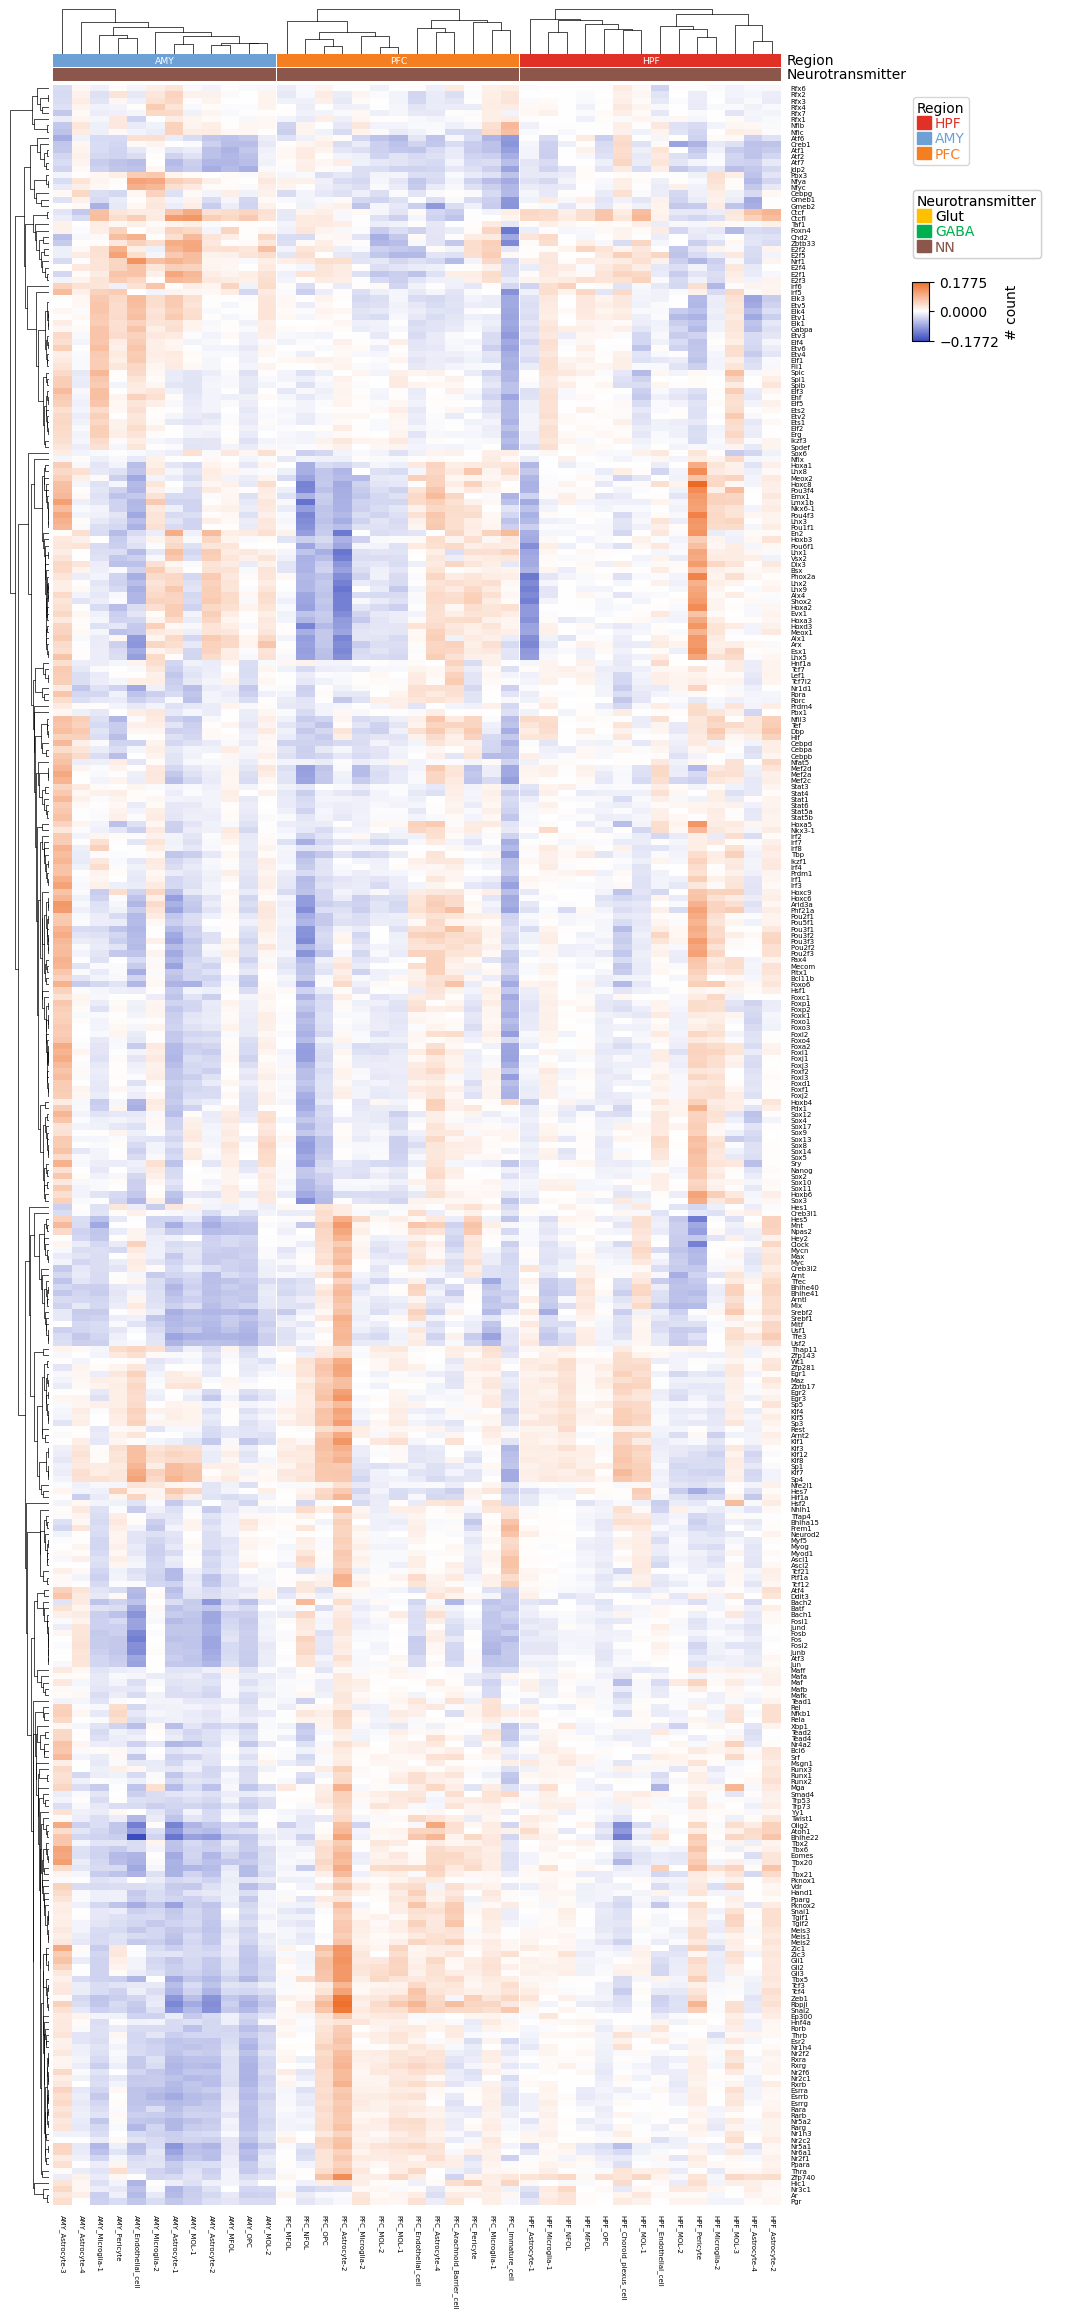

In [ ]:
cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')

In [83]:
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)

In [84]:
mat=cm.data2d.loc[row_names]

In [85]:
mat.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_mat.csv')

In [96]:
matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')

In [ ]:
denrow = cm.dendrogram_row

In [ ]:
cm.dendrogram_row.dendrogram.keys()

In [ ]:
n = len(cm.dendrogram_row.dendrogram["leaves"])
k = 10
labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [97]:
 focus=['Fos',
 'Junb',
 'Batf',
 'Fosl1',
 'Fosl2',
 'Jun',
 'Jund',
 'Atf3',
 'Bach1',
 'Bach2',
 'Fosb']

In [101]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [106]:
df_regions_focus = df_regions.loc[df_regions['TF'].isin(focus)]

In [108]:
df_regions_focus = df_regions_focus[df_regions_focus.absLog2FC>0.1]

In [111]:
df_regions_focus

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction,TF
13,chr1,3457979,3457991,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.25055,+,chr1,3457706,3458207,0.43410,0.72141,1,1,-0.70336,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Fos
25,chr1,5070450,5070462,metacluster_50.1homer__NDATGASTCAYN_Fos_None,8.49605,+,chr1,5070169,5070670,0.58746,0.66948,1,1,-0.18182,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,0.18182,PFC_L4-5_IT_Glut,chr1:5070169-5070670,Down,Fos
27,chr1,5208331,5208343,metacluster_50.1homer__NDATGASTCAYN_Fos_None,8.33921,+,chr1,5208069,5208570,0.21343,0.25563,1,1,-0.23676,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,0.23676,PFC_L4-5_IT_Glut,chr1:5208069-5208570,Down,Fos
32,chr1,6054355,6054367,metacluster_50.1homer__NDATGASTCAYN_Fos_None,8.96319,+,chr1,6054101,6054602,0.09268,0.17249,0,1,-0.75600,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,0.75600,PFC_L4-5_IT_Glut,chr1:6054101-6054602,Down,Fos
35,chr1,6214604,6214616,metacluster_50.1homer__NDATGASTCAYN_Fos_None,8.00786,+,chr1,6214368,6214869,1.06848,1.21565,1,1,-0.18245,/data2st2/junyi/output/atac1112/tobiasbam/PFC/...,0.18245,PFC_L4-5_IT_Glut,chr1:6214368-6214869,Down,Fos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,chrX,159672679,159672690,metacluster_157.2transfac_public__M00490_None,7.39687,-,chrX,159672391,159672892,1.73881,0.71226,1,0,1.10408,/data2st2/junyi/output/atac1112/tobiasbam/HIP/...,1.10408,HPF_MFOL,chrX:159672391-159672892,Up,Bach2
8690,chrX,159840479,159840490,metacluster_157.2transfac_public__M00490_None,8.57937,-,chrX,159840184,159840685,0.00000,1.60593,0,1,-3.30566,/data2st2/junyi/output/atac1112/tobiasbam/HIP/...,3.30566,HPF_MFOL,chrX:159840184-159840685,Down,Bach2
8694,chrX,162888454,162888465,metacluster_157.2transfac_public__M00490_None,9.53060,+,chrX,162888194,162888695,4.50340,3.42057,1,1,0.37927,/data2st2/junyi/output/atac1112/tobiasbam/HIP/...,0.37927,HPF_MFOL,chrX:162888194-162888695,Up,Bach2
8696,chrX,163064160,163064171,metacluster_157.2transfac_public__M00490_None,7.40089,-,chrX,163063876,163064377,0.00000,1.37097,0,1,-3.10224,/data2st2/junyi/output/atac1112/tobiasbam/HIP/...,3.10224,HPF_MFOL,chrX:163063876-163064377,Down,Bach2


In [129]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv",index_col=0)

In [134]:
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')

In [153]:
df_deg = df_deg[df_deg.Sex=='M']

In [163]:
df_deg

,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,Ensemble,Gene_name,Direction,Neurotransmitter,Region subclass,Region Subclass
Gene,,,,,,,,,,,,,,,,
Hspa5,5.379226e-06,-0.651779,-0.393220,-0.910339,2.495423e-02,2.495423e-02,Arachnoid Barrier cell,iCTX,M,MAST,ENSMUSG00000026864,"""Hspa5""",Down,NN,iCTX Arachnoid Barrier cell,iCTX_Arachnoid_Barrier_cell
2810049E08Rik,2.590297e-03,0.059091,0.092855,0.025327,3.093516e-02,1.000000e+00,Astrocyte-2,iCTX,M,MAST,ENSMUSG00000100891,"""2810049E08Rik""",Up,NN,iCTX Astrocyte-2,iCTX_Astrocyte-2
2900052N01Rik,4.506139e-03,-0.058958,-0.016975,-0.100941,4.575787e-02,1.000000e+00,Astrocyte-2,iCTX,M,MAST,ENSMUSG00000099696,"""2900052N01Rik""",Down,NN,iCTX Astrocyte-2,iCTX_Astrocyte-2
3222401L13Rik,1.456755e-03,-0.064914,-0.025388,-0.104441,2.024448e-02,1.000000e+00,Astrocyte-2,iCTX,M,MAST,ENSMUSG00000073590,"""3222401L13Rik""",Down,NN,iCTX Astrocyte-2,iCTX_Astrocyte-2
4632427E13Rik,4.688224e-03,-0.102958,-0.038874,-0.167042,4.678704e-02,1.000000e+00,Astrocyte-2,iCTX,M,MAST,ENSMUSG00000074024,"""4632427E13Rik""",Down,NN,iCTX Astrocyte-2,iCTX_Astrocyte-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Igfbp7,8.587061e-06,1.417962,2.535234,0.300690,1.293641e-02,2.587282e-02,Pericyte,MB,M,MAST,ENSMUSG00000036256,"""Igfbp7""",Up,NN,MB Pericyte,MB_Pericyte
Sparcl1,2.895168e-05,1.520709,2.331086,0.710333,1.749722e-02,8.723142e-02,Pericyte,MB,M,MAST,ENSMUSG00000029309,"""Sparcl1""",Up,NN,MB Pericyte,MB_Pericyte
Vtn,3.543182e-08,2.153221,3.105515,1.200926,1.067561e-04,1.067561e-04,Pericyte,MB,M,MAST,ENSMUSG00000017344,"""Vtn""",Up,NN,MB Pericyte,MB_Pericyte


In [154]:
df_gene_tobias = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name'],right_on=['Region Subclass','Gene'])

In [155]:
df_gene_consist = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name','Direction'],right_on=['Region Subclass','Gene','Direction'])

In [159]:
df_gene_consist

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,FDR,Bonferroni,Subclass,Region,Sex,Method,Ensemble,Gene_name,Neurotransmitter,Region subclass
0,chr1,3457979,3457991,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.24728,+,chr1,3457706,3458207,0.82955,...,1.581429e-04,2.512891e-01,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000051951,"""Xkr4""",Glut,PFC L2/3 IT Glut
1,chr1,3457979,3457991,metacluster_137.2homer__GGATGACTCATC_Fra2_None,9.68305,+,chr1,3457706,3458207,0.82955,...,1.581429e-04,2.512891e-01,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000051951,"""Xkr4""",Glut,PFC L2/3 IT Glut
2,chr1,3457980,3457990,metacluster_157.2homer__RATGASTCAT_JunB_None,8.88103,+,chr1,3457706,3458207,0.82955,...,1.581429e-04,2.512891e-01,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000051951,"""Xkr4""",Glut,PFC L2/3 IT Glut
3,chr1,3457981,3457990,metacluster_157.2dbtfbs__mm_FOSL1_C2C12_ENCSR0...,9.40513,-,chr1,3457706,3458207,0.82955,...,1.581429e-04,2.512891e-01,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000051951,"""Xkr4""",Glut,PFC L2/3 IT Glut
4,chr1,3457980,3457990,metacluster_137.2homer__ATGACTCATC_AP-1_None,9.61952,-,chr1,3457706,3458207,0.82955,...,1.581429e-04,2.512891e-01,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000051951,"""Xkr4""",Glut,PFC L2/3 IT Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199376,chr8,107367673,107367684,metacluster_50.1hocomoco__BATF_MOUSE.H11MO.1.A...,7.68084,-,chr8,107367345,107367846,0.06142,...,9.562322e-04,1.157041e-01,OPC,HPF,M,MAST,ENSMUSG00000003847,"""Nfat5""",NN,HPF OPC
199377,chr9,40806944,40806955,metacluster_50.1hocomoco__BATF_MOUSE.H11MO.1.A...,7.71358,+,chr9,40806865,40807366,0.39792,...,6.634146e-09,1.525854e-07,OPC,HPF,M,MAST,ENSMUSG00000015656,"""Hspa8""",NN,HPF OPC
199378,chr18,71366002,71366010,metacluster_157.2dbtfbs__mm_JUN_CH12.LX_ENCSR0...,8.03983,+,chr18,71365676,71366177,0.27608,...,8.001096e-04,9.281271e-02,OPC,HPF,M,MAST,ENSMUSG00000060534,"""Dcc""",NN,HPF OPC
199379,chr4,88412538,88412547,metacluster_137.2hocomoco__FOSB_MOUSE.H11MO.0....,7.74743,+,chr4,88412239,88412740,1.24752,...,1.303866e-02,1.000000e+00,HPF Subiculum SUB Glut,HPF,M,MAST,ENSMUSG00000028497,"""Hacd4""",Glut,HPF Subiculum SUB Glut


In [157]:
len(df_gene_tobias)

368071

In [ ]:
df_regions_focus = pd.merge(df_regions_focus,df_annotattion_columns,left_on='names',right_on='names')

KeyboardInterrupt: 

In [128]:
df_regions_focus

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,absLog2FC,Region Subclass,names,Direction,TF,gene_name,gene_id,gstart,gend,distance
0,chr1,3457979,3457991,metacluster_50.1homer__NDATGASTCAYN_Fos_None,9.25055,+,chr1,3457706,3458207,0.43410,...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Fos,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
1,chr1,3457979,3457991,metacluster_137.2homer__GGATGACTCATC_Fra2_None,9.68634,+,chr1,3457706,3458207,0.43410,...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Fosl2,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
2,chr1,3457981,3457990,metacluster_157.2dbtfbs__mm_FOSL1_C2C12_ENCSR0...,9.41138,-,chr1,3457706,3458207,0.43410,...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Fosl1,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
3,chr1,3457980,3457990,metacluster_157.2homer__RATGASTCAT_JunB_None,8.88966,+,chr1,3457706,3458207,0.43410,...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Junb,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
4,chr1,3457980,3457990,metacluster_137.2homer__ATGACTCATC_AP-1_None,9.62814,-,chr1,3457706,3458207,0.43410,...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Jun,Xkr4,ENSMUSG00000051951.5,3205900,3671498,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2918984,chr9,94998219,94998230,metacluster_157.2transfac_public__M00490_None,8.52142,+,chr9,94998075,94998576,0.47859,...,1.54540,HPF_MFOL,chr9:94998075-94998576,Down,Bach2,Slc9a9,ENSMUSG00000031129.9,94669908,95230445,0
2918985,chr9,110896345,110896356,metacluster_157.2transfac_public__M00490_None,7.83381,-,chr9,110895913,110896414,1.53756,...,1.45904,HPF_MFOL,chr9:110895913-110896414,Up,Bach2,Als2cl,ENSMUSG00000044037.15,110879869,110900530,0
2918986,chr9,120160195,120160206,metacluster_157.2transfac_public__M00490_None,8.33791,+,chr9,120159890,120160391,1.63304,...,1.70887,HPF_MFOL,chr9:120159890-120160391,Up,Bach2,Mobp,ENSMUSG00000032517.16,120149706,120181484,0
2918987,chr9,121808906,121808917,metacluster_157.2transfac_public__M00490_None,7.47874,-,chr9,121808444,121808945,1.63303,...,0.34033,HPF_MFOL,chr9:121808444-121808945,Down,Bach2,Ccdc13,ENSMUSG00000079235.10,121797626,121839461,0


In [127]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNP_dar_annotated.csvdir/tobias_focus.csv')

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [ ]:
focus

In [ ]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


In [ ]:
denrow.linkage

In [ ]:
cmnn = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC")

In [ ]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

In [ ]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [ ]:
df_3R

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
